# Etapa 5 — Clustering

**Pregunta:** ¿Qué perfiles de instituciones compradoras existen?  
**Unidad de análisis:** institución convocante (`convocante_limpio`)

## Objetivo

Segmentar las instituciones del Estado paraguayo según su perfil de compra, 
identificando patrones de comportamiento contractual que no son evidentes 
en el análisis individual.

## Variables de segmentación

Se construye un perfil por institución a partir de cuatro dimensiones:

- **Monto promedio** — escala de las contrataciones
- **Frecuencia** — cantidad de procesos en el período
- **Modalidad preferida** — proporción de contrataciones directas vs competitivas
- **Diversidad de proveedores** — cantidad de RUC distintos con los que opera

## Método

K-Means con normalización previa (StandardScaler). El número óptimo de 
clusters se determina mediante el método del codo y el coeficiente de 
silhouette.

## Consideraciones

- El clustering opera sobre instituciones, no sobre contratos individuales


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:_.2f}'.format


df = pd.read_csv("../datos/df_model.csv")
print(df.shape)

(25018, 32)


In [4]:
perfil = df.groupby("convocante_limpio").agg(
    monto_promedio=("monto_total_adjudicado", "mean"),
    frecuencia=("id_llamado", "count"),
    prop_directa=("tipo_proc_agrupado", lambda x: (x == "Contratación Directa").mean()),
    diversidad_proveedores=("ruc", "nunique")
).reset_index()

print(perfil.shape)
print(perfil.describe())

(398, 5)
          monto_promedio  frecuencia  prop_directa  diversidad_proveedores
count             398.00      398.00        398.00                  398.00
mean    1_628_865_174.14       62.86          0.60                   33.62
std     8_001_975_004.06      139.49          0.28                   48.87
min         8_024_000.00        1.00          0.00                    1.00
25%       143_721_101.31       12.00          0.40                    8.00
50%       211_778_418.39       31.00          0.63                   16.50
75%       486_530_101.71       70.00          0.83                   42.75
max   115_766_923_574.45    2_206.00          1.00                  497.00


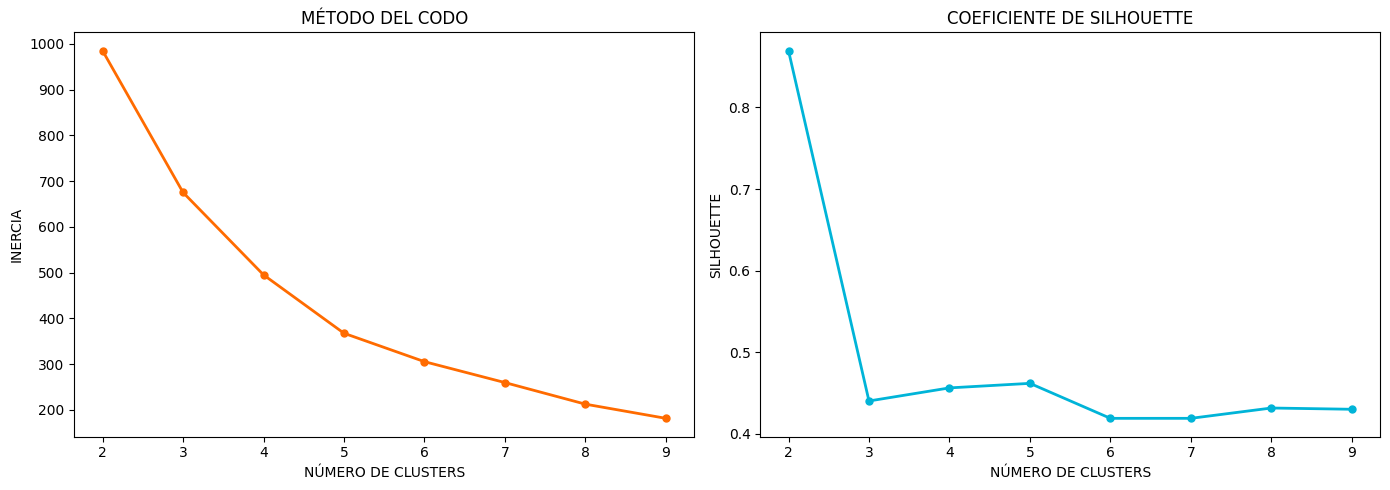


Silhouette por k:
  k=2: 0.8695
  k=3: 0.4402
  k=4: 0.4562
  k=5: 0.4618
  k=6: 0.4189
  k=7: 0.4189
  k=8: 0.4316
  k=9: 0.4300


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features_cluster = ["monto_promedio", "frecuencia", "prop_directa", "diversidad_proveedores"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(perfil[features_cluster])

# Método del codo + silhouette
inertias = []
silhouettes = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inertias, color="#FF6B00", linewidth=2, marker="o", markersize=5)
axes[0].set_title("MÉTODO DEL CODO")
axes[0].set_xlabel("NÚMERO DE CLUSTERS")
axes[0].set_ylabel("INERCIA")

axes[1].plot(K, silhouettes, color="#00B4D8", linewidth=2, marker="o", markersize=5)
axes[1].set_title("COEFICIENTE DE SILHOUETTE")
axes[1].set_xlabel("NÚMERO DE CLUSTERS")
axes[1].set_ylabel("SILHOUETTE")

plt.tight_layout()
plt.savefig("../figs/fig10_codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette por k:")
for k, s in zip(K, silhouettes):
    print(f"  k={k}: {s:.4f}")

## Determinación del número óptimo de clusters

Se usaron dos métodos complementarios:

**Método del codo** — grafica la inercia (suma de distancias al centroide) 
para cada valor de k. A medida que k aumenta la inercia siempre baja, 
pero el beneficio marginal disminuye. El "codo" es el punto donde agregar 
más clusters deja de justificarse — en este caso k=5.

**Coeficiente de Silhouette** — mide qué tan bien separados están los 
clusters. Varía entre -1 y 1:
- Cercano a 1 — los puntos están bien asignados a su cluster
- Cercano a 0 — los clusters se solapan
- Negativo — posible asignación incorrecta

k=2 obtiene el silhouette más alto (0.87) pero produce solo dos grupos — 
poco informativo para caracterizar perfiles institucionales diversos.
k=5 combina un silhouette aceptable (0.46) con granularidad suficiente 
para identificar perfiles diferenciados. Se selecciona k=5.

In [9]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
perfil["cluster"] = km.fit_predict(X_scaled)

print(perfil["cluster"].value_counts().sort_index())
print()
print(perfil.groupby("cluster")[features_cluster].mean().round(2).to_markdown(floatfmt="_.2f"))

cluster
0    144
1     28
2    222
3      1
4      3
Name: count, dtype: int64

|   cluster |    monto_promedio |   frecuencia |   prop_directa |   diversidad_proveedores |
|----------:|------------------:|-------------:|---------------:|-------------------------:|
|         0 |  1_131_449_335.01 |        38.62 |           0.34 |                    25.08 |
|         1 |  4_857_500_595.99 |       247.64 |           0.33 |                   135.57 |
|         2 |    350_622_238.13 |        38.38 |           0.81 |                    21.23 |
|         3 | 39_713_832_759.93 |     2_206.00 |           0.22 |                   497.00 |
|         4 | 77_265_882_917.46 |       598.67 |           0.09 |                   254.67 |


In [11]:
print(perfil[perfil["cluster"] == 3]["convocante_limpio"].values.tolist())
print(perfil[perfil["cluster"] == 4]["convocante_limpio"].values.tolist())

['Ministerio de Salud Pública y Bienestar Social']
['Administración Nacional de Electricidad', 'Instituto de Previsión Social', 'Ministerio de Obras Públicas y Comunicaciones']


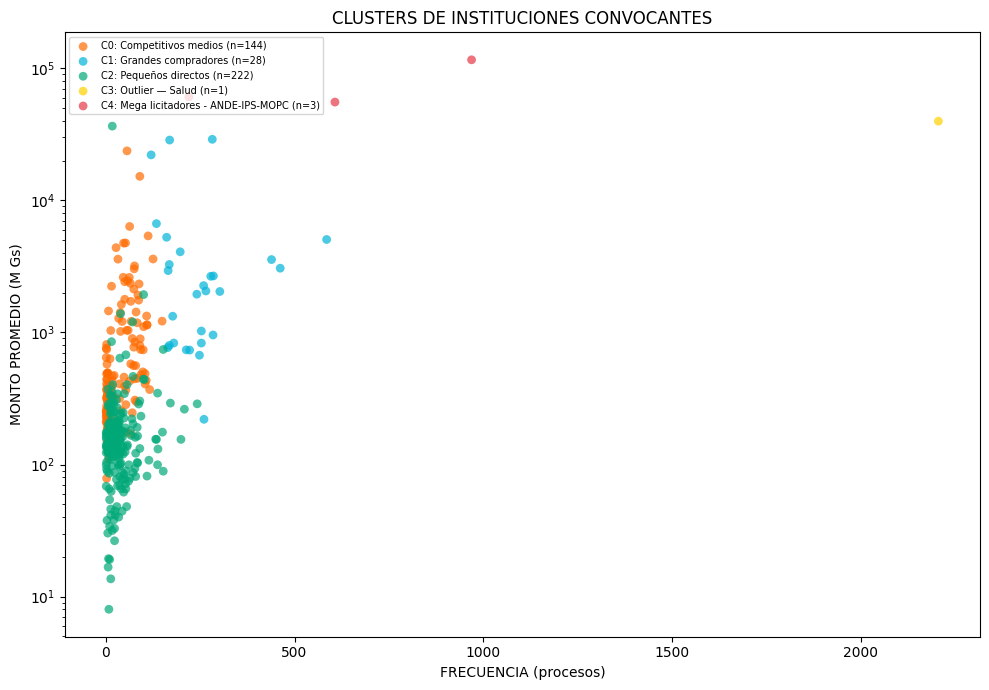

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

colores = ["#FF6B00", "#00B4D8", "#00A878", "#FFD100", "#E63946"]
labels = ["Competitivos medios", "Grandes compradores", 
          "Pequeños directos", "Outlier — Salud", "Mega licitadores - ANDE-IPS-MOPC"]

for cluster in range(5):
    mask = perfil["cluster"] == cluster
    ax.scatter(
        perfil[mask]["frecuencia"],
        perfil[mask]["monto_promedio"] / 1e6,
        c=colores[cluster],
        label=f"C{cluster}: {labels[cluster]} (n={mask.sum()})",
        alpha=0.7, s=40, edgecolor="none"
    )

ax.set_title("CLUSTERS DE INSTITUCIONES CONVOCANTES")
ax.set_xlabel("FRECUENCIA (procesos)")
ax.set_ylabel("MONTO PROMEDIO (M Gs)")
ax.set_yscale("log")
ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("../figs/fig11_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## Perfiles de instituciones convocantes — K-Means k=5

La segmentación revela cinco perfiles diferenciados de comportamiento 
contractual en el Estado paraguayo.

**Cluster 0 — Competitivos medios (144 instituciones)**  
Frecuencia moderada, monto medio, baja proporción de contratación directa (34%). 
Instituciones que operan con procesos competitivos pero a escala intermedia.

**Cluster 1 — Grandes compradores (28 instituciones)**  
Alta frecuencia (248 procesos promedio), montos altos, baja contratación 
directa (33%), alta diversidad de proveedores (136). El grupo más activo 
en licitaciones competitivas de alto volumen.

**Cluster 2 — Pequeños directos (222 instituciones)**  
El cluster más numeroso. Montos bajos, frecuencia moderada, altísima 
proporción de contratación directa (81%). Instituciones pequeñas que 
evitan los procesos competitivos — patrón que merece atención desde 
la perspectiva de transparencia.

**Cluster 3 — Outlier: Ministerio de Salud (1 institución)**  
Caso único. 2.206 procesos, 497 proveedores distintos, monto promedio 
de 39.700M Gs. El mayor comprador del Estado paraguayo por amplísimo 
margen — su volumen lo separa completamente del resto.

**Cluster 4 — Mega licitadores (3 instituciones)**  
ANDE, IPS y MOPC. Contratos de valor extremo (77.000M Gs promedio), 
alta diversidad de proveedores y la proporción más baja de contratación 
directa (9%) — las instituciones más competitivas y transparentes del dataset.



In [14]:
perfil.to_csv("../datos/df_clusters.csv", index=False)
print("Guardado.")
print(perfil.shape)

Guardado.
(398, 6)
